<a href="https://colab.research.google.com/github/kamalrajarulprakasam-sudo/BronzeBadge_GenAIAssignments/blob/main/Problem4_HousePricePrediction_3D_Visualization/house_price_3d_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problem 4: House Price Prediction — 3D Visualization
## Linear Regression with 3D Surface Plots

---
**Course:** L3-L5 Gen AI App Developer | Bronze Badge  
**Topic:** Regression + 3D Data Visualization  

### Problem Statement
Draw **3D plots** visualizing the regression model for **house price prediction**.

### Features Used
| Feature | Unit | Description |
|---------|------|-------------|
| Area (sq ft) | sq ft | Total built-up area of the house |
| Number of Bedrooms | Count | Number of bedrooms (1–6) |

### Target Variable
**House Price** — In lakhs (₹), range approx ₹20L – ₹200L

### Visualizations Included
1. **3D Scatter Plot** (matplotlib)
2. **3D Regression Plane** (matplotlib surface)
3. **Interactive 3D Scatter** (Plotly)
4. **Interactive 3D Surface** (Plotly)
5. **Contour / Heatmap** of predicted prices

In [1]:
# ============================================================
# STEP 1: Import Required Libraries
# ============================================================

import numpy as np                      # Numerical operations
import pandas as pd                     # Data manipulation
import matplotlib.pyplot as plt         # 2D/3D plotting
import matplotlib.cm as cm              # Colormaps
from mpl_toolkits.mplot3d import Axes3D # 3D plotting toolkit for matplotlib
import seaborn as sns                   # Statistical visualizations
from sklearn.linear_model import LinearRegression  # Linear regression model
from sklearn.metrics import r2_score, mean_squared_error  # Evaluation metrics
from sklearn.preprocessing import PolynomialFeatures      # For polynomial regression
import warnings
warnings.filterwarnings('ignore')

# Try to import Plotly for interactive 3D plots
try:
    import plotly.graph_objects as go      # Plotly 3D graph objects
    import plotly.express as px            # High-level Plotly interface
    PLOTLY_AVAILABLE = True
    print('Plotly is available: Interactive 3D plots will be generated')
except ImportError:
    PLOTLY_AVAILABLE = False
    print('Plotly not installed. Run: pip install plotly')
    print('Matplotlib 3D plots will still be generated')

print('Step 1 COMPLETE: All libraries imported!')

Plotly is available: Interactive 3D plots will be generated
Step 1 COMPLETE: All libraries imported!


In [2]:
# ============================================================
# STEP 2: Create Extended House Price Dataset
# ============================================================
# 40 data points with realistic Indian real estate pricing
# Price modeled as: Price = base + area_factor*Area + bedroom_premium*Bedrooms + noise

np.random.seed(42)   # Fix seed for reproducibility

# House attributes
area_sqft = np.array([
     600,  750,  850,  950, 1050, 1100, 1200, 1350, 1500, 1650,
    1700, 1850, 1950, 2000, 2100, 2200, 2350, 2500, 2700, 2900,
     680,  820,  920, 1020, 1150, 1280, 1450, 1620, 1780, 1920,
    2050, 2180, 2380, 2550, 2750, 2950, 3100, 3300, 3500, 3800
])  # Area in square feet

bedrooms = np.array([
    1, 1, 2, 2, 2, 2, 3, 3, 3, 3,
    3, 3, 4, 4, 4, 4, 4, 5, 5, 5,
    1, 2, 2, 2, 3, 3, 3, 3, 4, 4,
    4, 4, 4, 5, 5, 5, 5, 6, 6, 6
])  # Number of bedrooms (1–6)

# Realistic pricing formula:
# Base price + area contribution (₹3500/sq ft) + bedroom premium (₹5L/bedroom) + noise
noise = np.random.normal(0, 5, len(area_sqft))  # Random noise ±5 lakhs
price_lakhs = (10 + area_sqft * 0.035 + bedrooms * 5.0 + noise).round(2)

# Ensure no negative prices (clip at minimum ₹20L)
price_lakhs = np.maximum(price_lakhs, 20)

# Create DataFrame
df = pd.DataFrame({
    'Area_sqft':    area_sqft,
    'Bedrooms':     bedrooms,
    'Price_Lakhs':  price_lakhs
})

print(f'Dataset Shape: {df.shape}')
print('\nFirst 10 records:')
print(df.head(10).to_string())
print('\nStatistical Summary:')
print(df.describe().round(2))
print(f'\nPrice Range: ₹{price_lakhs.min():.1f}L  to  ₹{price_lakhs.max():.1f}L')

Dataset Shape: (40, 3)

First 10 records:
   Area_sqft  Bedrooms  Price_Lakhs
0        600         1        38.48
1        750         1        40.56
2        850         2        52.99
3        950         2        60.87
4       1050         2        55.58
5       1100         2        57.33
6       1200         3        74.90
7       1350         3        76.09
8       1500         3        75.15
9       1650         3        85.46

Statistical Summary:
       Area_sqft  Bedrooms  Price_Lakhs
count      40.00     40.00        40.00
mean     1861.25      3.50        91.55
std       839.77      1.38        34.57
min       600.00      1.00        38.48
25%      1137.50      2.75        62.12
50%      1815.00      3.50        88.36
75%      2410.00      4.25       116.41
max      3800.00      6.00       173.98

Price Range: ₹38.5L  to  ₹174.0L


In [3]:
# ============================================================
# STEP 3: Train Linear Regression Model
# ============================================================

X = df[['Area_sqft', 'Bedrooms']]   # Features
y = df['Price_Lakhs']                # Target

model = LinearRegression()
model.fit(X, y)  # Train on full dataset (for visualization purposes)

y_pred = model.predict(X)   # Predictions
r2  = r2_score(y, y_pred)   # R-squared
mse = mean_squared_error(y, y_pred)  # MSE

print('=== REGRESSION MODEL RESULTS ===')
print(f'Intercept (β0):             {model.intercept_:.4f} Lakhs')
print(f'Coefficient (β1, Area):     {model.coef_[0]:.4f} Lakhs per sq ft')
print(f'Coefficient (β2, Bedrooms): {model.coef_[1]:.4f} Lakhs per bedroom')
print(f'\nR² Score:  {r2:.4f}  ({r2*100:.1f}% variance explained)')
print(f'RMSE:      {np.sqrt(mse):.4f} Lakhs')

print(f'\nREGRESSION EQUATION:')
print(f'  Price = {model.intercept_:.2f} + {model.coef_[0]:.4f}×Area + {model.coef_[1]:.2f}×Bedrooms')

# Generate the regression surface grid for plotting
# Create a meshgrid spanning the feature ranges
area_range = np.linspace(area_sqft.min(), area_sqft.max(), 50)   # 50 area values
bed_range  = np.linspace(bedrooms.min(),  bedrooms.max(),  50)   # 50 bedroom values

area_grid, bed_grid = np.meshgrid(area_range, bed_range)   # 50×50 grid

# Flatten, predict, then reshape back to grid for surface plotting
grid_features = np.column_stack([area_grid.ravel(), bed_grid.ravel()])  # (2500, 2)
price_surface = model.predict(grid_features).reshape(area_grid.shape)   # (50, 50)

print('\nRegression surface grid computed for 3D plotting!')

=== REGRESSION MODEL RESULTS ===
Intercept (β0):             13.5996 Lakhs
Coefficient (β1, Area):     0.0350 Lakhs per sq ft
Coefficient (β2, Bedrooms): 3.6375 Lakhs per bedroom

R² Score:  0.9839  (98.4% variance explained)
RMSE:      4.3374 Lakhs

REGRESSION EQUATION:
  Price = 13.60 + 0.0350×Area + 3.64×Bedrooms

Regression surface grid computed for 3D plotting!


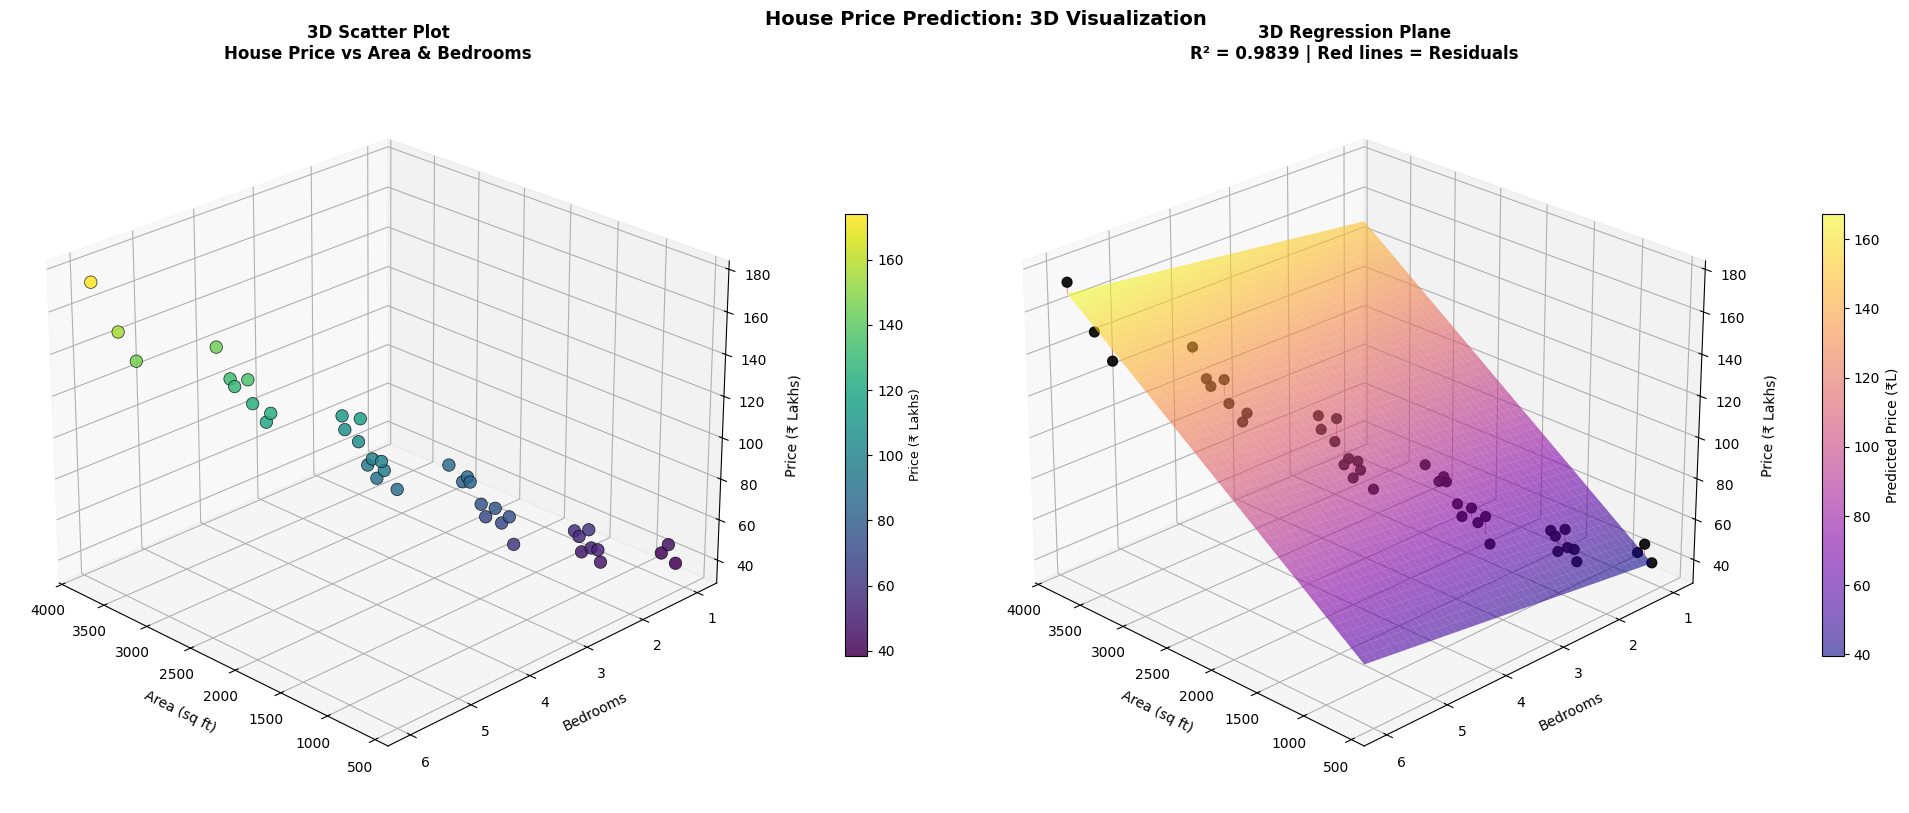

Saved: house_price_3d_matplotlib.png


In [4]:
# ============================================================
# STEP 4: Matplotlib 3D Scatter + Regression Plane
# ============================================================
# Plot 1: Pure 3D scatter (data points only)
# Plot 2: Scatter + regression surface (semi-transparent plane)

fig = plt.figure(figsize=(20, 8))

# ---- Plot 1: 3D Scatter Plot ----
ax1 = fig.add_subplot(121, projection='3d')   # 3D axes

# Color points by price (using a colormap)
scatter_colors = cm.viridis(  # viridis: purple → yellow (low → high)
    (price_lakhs - price_lakhs.min()) / (price_lakhs.max() - price_lakhs.min())
)

sc = ax1.scatter(
    df['Area_sqft'],     # X axis
    df['Bedrooms'],      # Y axis
    df['Price_Lakhs'],   # Z axis
    c=price_lakhs,       # Color by price value
    cmap='viridis',      # Color map
    s=80,                # Marker size
    edgecolors='black',  # Marker border
    linewidths=0.5,
    alpha=0.85,
    zorder=5
)

# Axis labels and title
ax1.set_xlabel('Area (sq ft)', fontsize=10, labelpad=8)
ax1.set_ylabel('Bedrooms', fontsize=10, labelpad=8)
ax1.set_zlabel('Price (₹ Lakhs)', fontsize=10, labelpad=8)
ax1.set_title('3D Scatter Plot\nHouse Price vs Area & Bedrooms',
              fontsize=12, fontweight='bold')
ax1.view_init(elev=25, azim=135)   # Set viewing angle

# Add color bar
cbar = fig.colorbar(sc, ax=ax1, shrink=0.6, pad=0.1)
cbar.set_label('Price (₹ Lakhs)', fontsize=9)

# ---- Plot 2: 3D Scatter + Regression Plane ----
ax2 = fig.add_subplot(122, projection='3d')

# Plot the regression surface (semi-transparent plane)
surf = ax2.plot_surface(
    area_grid,        # X values of grid
    bed_grid,         # Y values of grid
    price_surface,    # Z values (predicted prices on the plane)
    cmap='plasma',    # Color map for the surface
    alpha=0.6,        # Semi-transparent to see data points through it
    edgecolor='none'  # No grid lines on surface
)

# Overlay actual data points on top of the surface
ax2.scatter(
    df['Area_sqft'],
    df['Bedrooms'],
    df['Price_Lakhs'],
    color='black', s=50, zorder=5, alpha=0.9, label='Actual Data'
)

# Draw vertical lines from actual to predicted (residuals)
for i in range(len(df)):
    ax2.plot(
        [df['Area_sqft'].iloc[i], df['Area_sqft'].iloc[i]],   # X same
        [df['Bedrooms'].iloc[i],  df['Bedrooms'].iloc[i]],    # Y same
        [y_pred[i],               df['Price_Lakhs'].iloc[i]], # Z: from predicted to actual
        color='red', linewidth=0.6, alpha=0.5  # Red residual lines
    )

ax2.set_xlabel('Area (sq ft)', fontsize=10, labelpad=8)
ax2.set_ylabel('Bedrooms', fontsize=10, labelpad=8)
ax2.set_zlabel('Price (₹ Lakhs)', fontsize=10, labelpad=8)
ax2.set_title(f'3D Regression Plane\nR² = {r2:.4f} | Red lines = Residuals',
              fontsize=12, fontweight='bold')
ax2.view_init(elev=25, azim=135)
fig.colorbar(surf, ax=ax2, shrink=0.6, pad=0.1, label='Predicted Price (₹L)')

plt.suptitle('House Price Prediction: 3D Visualization', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('house_price_3d_matplotlib.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: house_price_3d_matplotlib.png')

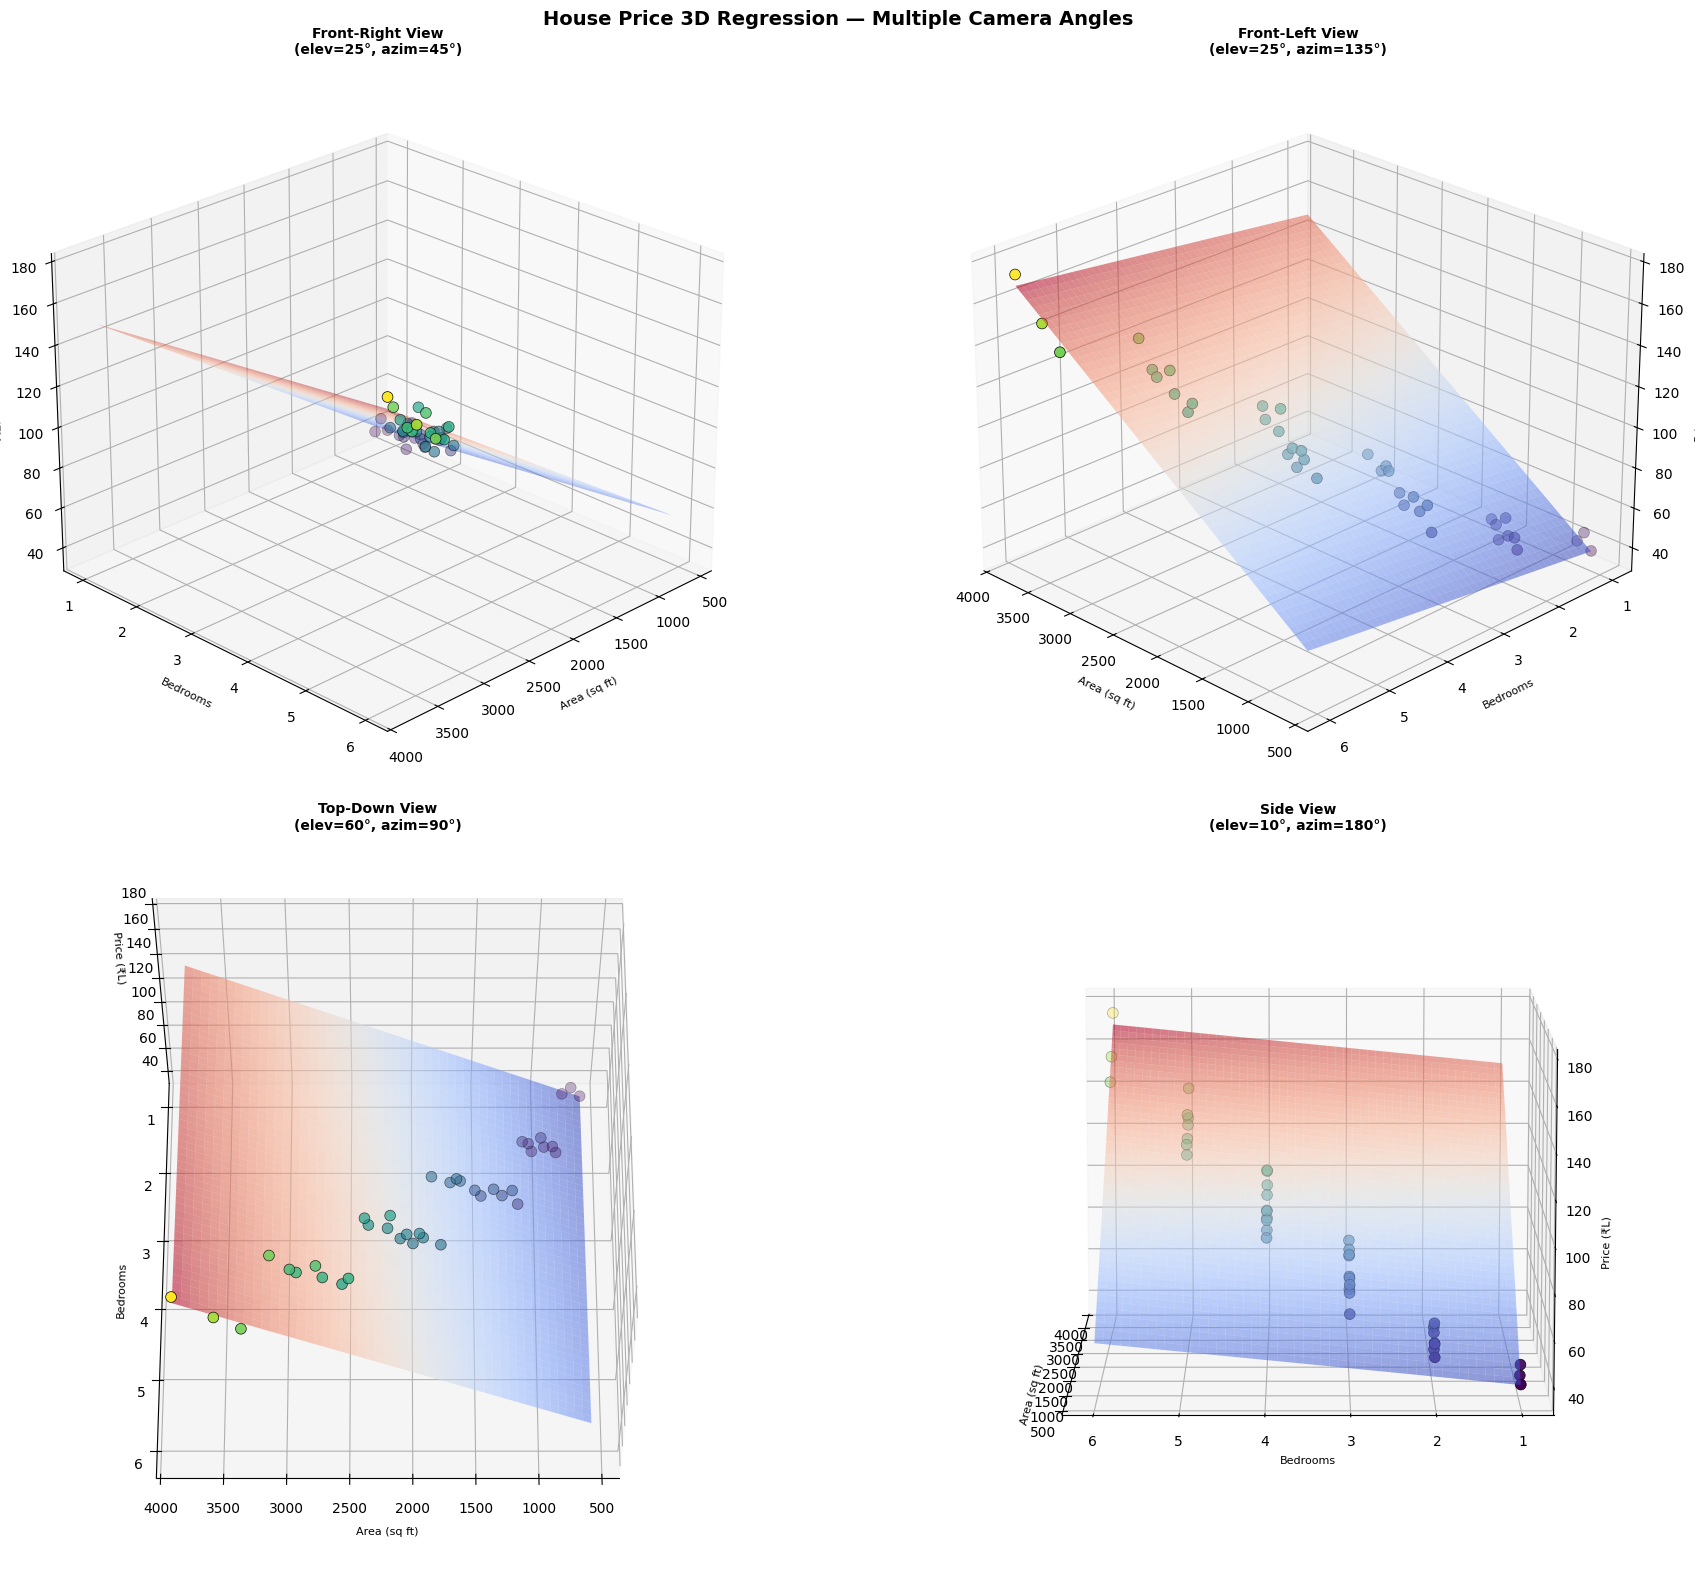

In [5]:
# ============================================================
# STEP 5: Multiple Viewing Angles of the 3D Plot
# ============================================================
# Same plot from 4 different camera angles to aid interpretation

fig = plt.figure(figsize=(20, 16))

# Camera angles: (elevation, azimuth) in degrees
angles = [(25, 45), (25, 135), (60, 90), (10, 180)]
angle_names = ['Front-Right View', 'Front-Left View', 'Top-Down View', 'Side View']

for plot_i, ((elev, azim), angle_name) in enumerate(zip(angles, angle_names)):
    ax = fig.add_subplot(2, 2, plot_i+1, projection='3d')  # 2×2 grid

    # Regression surface
    surf = ax.plot_surface(area_grid, bed_grid, price_surface,
                           cmap='coolwarm', alpha=0.55, edgecolor='none')

    # Data scatter
    ax.scatter(df['Area_sqft'], df['Bedrooms'], df['Price_Lakhs'],
               c=price_lakhs, cmap='viridis', s=60,
               edgecolors='black', linewidths=0.5, zorder=5)

    ax.view_init(elev=elev, azim=azim)   # Set camera angle
    ax.set_xlabel('Area (sq ft)', fontsize=8, labelpad=5)
    ax.set_ylabel('Bedrooms', fontsize=8, labelpad=5)
    ax.set_zlabel('Price (₹L)', fontsize=8, labelpad=5)
    ax.set_title(f'{angle_name}\n(elev={elev}°, azim={azim}°)',
                 fontsize=10, fontweight='bold')

plt.suptitle('House Price 3D Regression — Multiple Camera Angles', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [6]:
# ============================================================
# STEP 6: Interactive 3D Plot using Plotly
# ============================================================
# Plotly creates interactive HTML plots:
# - Rotate by clicking and dragging
# - Zoom with scroll wheel
# - Hover to see exact values

if PLOTLY_AVAILABLE:

    # --- Interactive 3D Scatter ---
    fig_scatter = px.scatter_3d(
        df,
        x='Area_sqft',
        y='Bedrooms',
        z='Price_Lakhs',
        color='Price_Lakhs',                # Color by price
        color_continuous_scale='Viridis',   # Color scale
        size='Price_Lakhs',                 # Size by price
        size_max=15,
        opacity=0.85,
        title='Interactive 3D Scatter: House Price vs Area & Bedrooms',
        labels={
            'Area_sqft'  : 'Area (sq ft)',
            'Bedrooms'   : 'Number of Bedrooms',
            'Price_Lakhs': 'Price (₹ Lakhs)'
        },
        hover_data=['Area_sqft', 'Bedrooms', 'Price_Lakhs']  # Tooltip data
    )

    fig_scatter.update_layout(
        scene=dict(
            xaxis_title='Area (sq ft)',
            yaxis_title='Bedrooms',
            zaxis_title='Price (₹ Lakhs)'
        ),
        width=900, height=650
    )
    fig_scatter.show()   # Opens interactive plot in notebook
    fig_scatter.write_html('house_price_scatter_3d.html')  # Save as HTML
    print('Interactive scatter saved: house_price_scatter_3d.html')

    # --- Interactive 3D Surface (Regression Plane) ---
    fig_surface = go.Figure()

    # Add regression surface
    fig_surface.add_trace(go.Surface(
        x=area_range,
        y=bed_range,
        z=price_surface,
        colorscale='RdBu',       # Blue (low) → Red (high)
        opacity=0.75,
        name='Regression Surface',
        showscale=True,
        colorbar=dict(title='Predicted Price (₹L)')
    ))

    # Add actual data points on top of surface
    fig_surface.add_trace(go.Scatter3d(
        x=df['Area_sqft'],
        y=df['Bedrooms'],
        z=df['Price_Lakhs'],
        mode='markers',
        marker=dict(size=5, color='black', opacity=0.9, symbol='circle'),
        name='Actual Data Points',
        hovertemplate=(
            '<b>Area: %{x} sq ft</b><br>'
            'Bedrooms: %{y}<br>'
            'Actual Price: ₹%{z:.1f}L<extra></extra>'
        )
    ))

    fig_surface.update_layout(
        title=dict(text=f'Interactive 3D Regression Surface<br>R² = {r2:.4f}', font=dict(size=15)),
        scene=dict(
            xaxis_title='Area (sq ft)',
            yaxis_title='Bedrooms',
            zaxis_title='Price (₹ Lakhs)'
        ),
        width=950, height=700
    )
    fig_surface.show()
    fig_surface.write_html('house_price_surface_3d.html')
    print('Interactive surface saved: house_price_surface_3d.html')

else:
    print('Plotly not available. Install it with: pip install plotly')
    print('Matplotlib 3D plots were already shown in Step 4.')

Interactive scatter saved: house_price_scatter_3d.html


Interactive surface saved: house_price_surface_3d.html


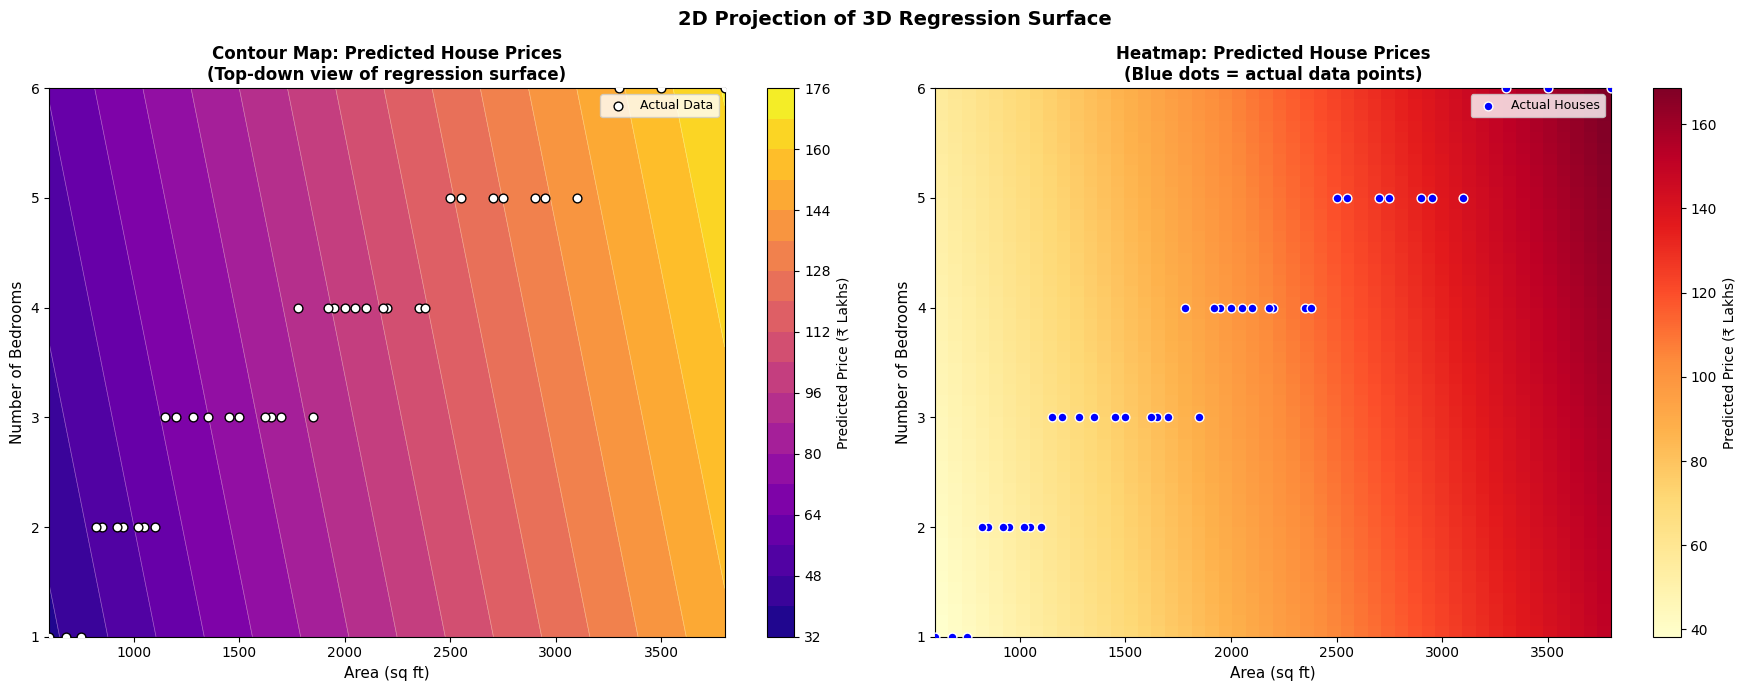

Contour and heatmap saved: house_price_contour_heatmap.png


In [7]:
# ============================================================
# STEP 7: 2D Contour / Heatmap of Predicted Prices
# ============================================================
# A 2D top-down view of the regression surface
# Each color zone shows the predicted price range for that Area-Bedrooms combination

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Plot 1: Filled Contour (Contourf) ---
levels = 20  # Number of contour levels
contour = axes[0].contourf(
    area_range, bed_range, price_surface,
    levels=levels, cmap='plasma'
)
# Add contour lines on top
axes[0].contour(
    area_range, bed_range, price_surface,
    levels=levels, colors='white', alpha=0.4, linewidths=0.5
)

# Overlay actual data points
axes[0].scatter(df['Area_sqft'], df['Bedrooms'],
                c='white', s=40, edgecolors='black', linewidths=1.0,
                zorder=5, label='Actual Data')

fig.colorbar(contour, ax=axes[0], label='Predicted Price (₹ Lakhs)')
axes[0].set_xlabel('Area (sq ft)', fontsize=11)
axes[0].set_ylabel('Number of Bedrooms', fontsize=11)
axes[0].set_title('Contour Map: Predicted House Prices\n(Top-down view of regression surface)',
                   fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)

# --- Plot 2: Heatmap (imshow) ---
# Show fine-grained prediction grid as a heatmap
im = axes[1].imshow(
    price_surface,
    origin='lower',
    aspect='auto',
    extent=[area_range.min(), area_range.max(), bed_range.min(), bed_range.max()],
    cmap='YlOrRd'  # Yellow → Orange → Red (low → high price)
)

# Overlay actual points
axes[1].scatter(df['Area_sqft'], df['Bedrooms'],
                c='blue', s=40, edgecolors='white', zorder=5, label='Actual Houses')

fig.colorbar(im, ax=axes[1], label='Predicted Price (₹ Lakhs)')
axes[1].set_xlabel('Area (sq ft)', fontsize=11)
axes[1].set_ylabel('Number of Bedrooms', fontsize=11)
axes[1].set_title('Heatmap: Predicted House Prices\n(Blue dots = actual data points)',
                   fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('2D Projection of 3D Regression Surface', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('house_price_contour_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()
print('Contour and heatmap saved: house_price_contour_heatmap.png')

=== PRICE PREDICTIONS FOR NEW PROPERTIES ===
   Area_sqft  Bedrooms  Predicted_Price_Lakhs
0        800         2                  48.91
1       1200         3                  66.56
2       1500         3                  77.07
3       2000         4                  98.23
4       2500         4                 115.75
5       3000         5                 136.91
6       3500         6                 158.07

Property Segments:
   Area_sqft  Bedrooms  Predicted_Price_Lakhs                Category
0        800         2                  48.91         Budget (< ₹50L)
1       1200         3                  66.56  Mid-Range (₹50L–₹100L)
2       1500         3                  77.07  Mid-Range (₹50L–₹100L)
3       2000         4                  98.23  Mid-Range (₹50L–₹100L)
4       2500         4                 115.75   Premium (₹100L–₹150L)
5       3000         5                 136.91   Premium (₹100L–₹150L)
6       3500         6                 158.07        Luxury (> ₹150L)


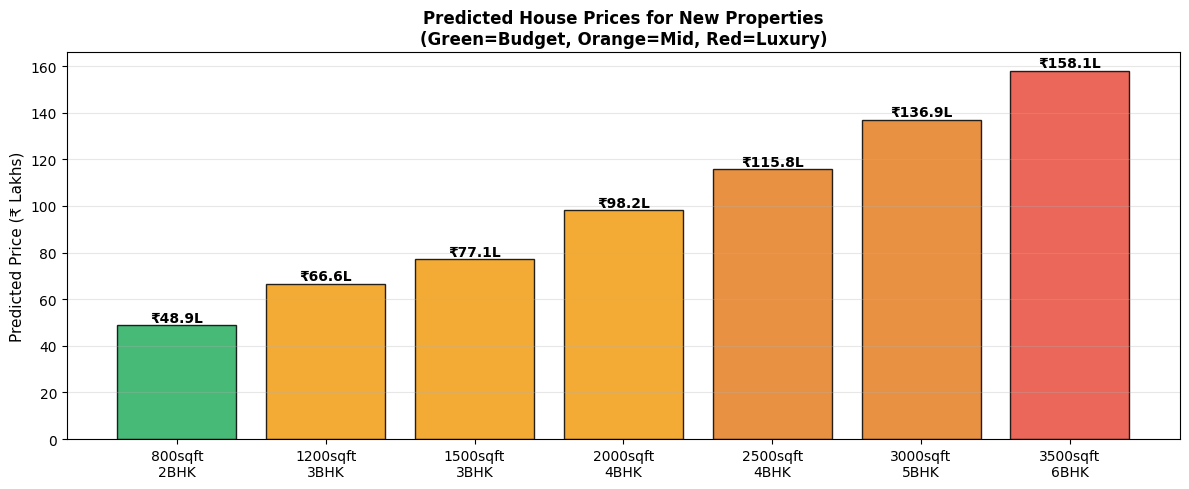

In [8]:
# ============================================================
# STEP 8: Predict House Prices for New Properties
# ============================================================

new_houses = pd.DataFrame({
    'Area_sqft': [800,  1200, 1500, 2000, 2500, 3000, 3500],
    'Bedrooms':  [2,    3,    3,    4,    4,    5,    6   ]
})

new_prices = model.predict(new_houses).round(2)   # Predict prices
new_houses['Predicted_Price_Lakhs'] = new_prices

print('=== PRICE PREDICTIONS FOR NEW PROPERTIES ===')
print(new_houses.to_string(index=True))

# Price category labels
def price_category(p):
    if p < 50:   return 'Budget (< ₹50L)'
    elif p < 100: return 'Mid-Range (₹50L–₹100L)'
    elif p < 150: return 'Premium (₹100L–₹150L)'
    else:         return 'Luxury (> ₹150L)'

new_houses['Category'] = new_houses['Predicted_Price_Lakhs'].apply(price_category)
print('\nProperty Segments:')
print(new_houses[['Area_sqft', 'Bedrooms', 'Predicted_Price_Lakhs', 'Category']].to_string())

# Visual bar chart
seg_colors = ['#27ae60' if p < 50 else '#f39c12' if p < 100 else '#e67e22' if p < 150
              else '#e74c3c' for p in new_prices]
plt.figure(figsize=(12, 5))
labels = [f'{int(r.Area_sqft)}sqft\n{r.Bedrooms}BHK' for r in new_houses.itertuples()]
bars = plt.bar(labels, new_prices, color=seg_colors, edgecolor='black', alpha=0.85)
for bar, val in zip(bars, new_prices):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
             f'₹{val:.1f}L', ha='center', fontsize=10, fontweight='bold')
plt.ylabel('Predicted Price (₹ Lakhs)', fontsize=11)
plt.title('Predicted House Prices for New Properties\n(Green=Budget, Orange=Mid, Red=Luxury)',
          fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# STEP 9: Key Insights from the 3D Visualization

## What the 3D Regression Plane Tells Us

1. **Linear Plane**: The regression model fits a **flat plane** through 3D space, meaning both Area and Bedrooms have linear, additive effects on price.

2. **Slope Along Area Axis**: The plane rises steeply as Area increases → **Area has a strong positive effect** on price (₹~3,500 per sq ft added).

3. **Slope Along Bedrooms Axis**: The plane also rises with more bedrooms but less steeply than area → **Bedrooms add a premium** but area is the dominant factor.

4. **Residuals** (red vertical lines): Points above the plane = underestimated (actual > predicted). Points below = overestimated. Uniform scatter = good linear fit.

## Limitations of This Model
- **Location** (area code, neighborhood) is a major missing feature
- **Non-linear effects**: price per sq ft often varies non-linearly
- **Amenities** (parking, floor, age) not included
- **Polynomial Regression** would better capture curved surfaces

## Choosing Between Matplotlib and Plotly
| | Matplotlib 3D | Plotly 3D |
|--|--------------|----------|
| **Interactivity** | None (static) | Full (rotate, zoom, hover) |
| **Export** | PNG/PDF/SVG | HTML/PNG/PDF |
| **Use case** | Reports, publications | Dashboards, presentations |
| **Complexity** | Low | Medium |